In [ ]:
with their tatiomn # =========================================================
# Section 1: Environment Setup
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("Environment setup complete")
print("\n")

# =========================================================
# Section 2: Data Loading
# =========================================================

business_df = pd.read_csv("Businesses.csv")
credit_rating_df = pd.read_csv("Credit_Rating.csv")
loan_df = pd.read_csv("Loan.csv")
credit_account_df = pd.read_csv("Credit_Account_History.csv")
credit_card_df = pd.read_csv("Credit_Card_History.csv")
receivable_df = pd.read_csv("Account_Receivable.csv")
factoring_df = pd.read_csv("Factoring.csv")
covid_df = pd.read_csv("COVID.csv")
]


print("Dataset shapes:")
print(f"Business: {business_df.shape}")
print(f"Credit Rating: {credit_rating_df.shape}")
print(f"Loan: {loan_df.shape}")
print(f"Credit Account: {credit_account_df.shape}")
print(f"Credit Card: {credit_card_df.shape}")
print(f"Receivable: {receivable_df.shape}")
print(f"Factoring: {factoring_df.shape}")
print(f"COVID: {covid_df.shape}")
print("\n")

# =========================================================
# Section 3: One-to-Many Relationship Aggregation
# =========================================================

print("Aggregating one-to-many relationships to firm level...")

if 'Unnamed: 0' in receivable_df.columns:
    receivable_df = receivable_df.drop(columns=['Unnamed: 0'])

receivable_agg = receivable_df.groupby('company_reg_number').agg({
    'invoice_amount': ['sum', 'mean', 'count'],
    'disputed': 'sum'
}).reset_index()
receivable_agg.columns = ['company_reg_number', 'total_invoice_amount', 'mean_invoice_amount',
                           'invoice_count', 'total_disputed']

print(f"Receivable aggregated shape: {receivable_agg.shape}")

if 'Unnamed: 0' in credit_account_df.columns:
    credit_account_df = credit_account_df.drop(columns=['Unnamed: 0'])

numeric_cols_credit_account = credit_account_df.select_dtypes(include=[np.number]).columns.tolist()
if 'company_reg_number' in numeric_cols_credit_account:
    numeric_cols_credit_account.remove('company_reg_number')

if numeric_cols_credit_account:
    agg_dict = {col: 'mean' for col in numeric_cols_credit_account}
    credit_account_agg = credit_account_df.groupby('company_reg_number').agg(agg_dict).reset_index()
else:
    credit_account_agg = credit_account_df[['company_reg_number']].drop_duplicates()

print(f"Credit account aggregated shape: {credit_account_agg.shape}")
print("\n")

# =========================================================
# Section 4: Dataset Integration
# =========================================================

for df_name in ['business_df', 'credit_rating_df', 'loan_df',
                'credit_card_df', 'factoring_df', 'covid_df']:
    df_obj = globals()[df_name]
    if 'Unnamed: 0' in df_obj.columns:
        globals()[df_name] = df_obj.drop(columns=['Unnamed: 0'])

df = business_df.copy()
df = df.merge(credit_rating_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(loan_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(credit_account_agg, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(credit_card_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(receivable_agg, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(factoring_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(covid_df, on='company_reg_number', how='left', suffixes=('', '_dup'))

duplicate_cols = [col for col in df.columns if col.endswith('_dup')]
if duplicate_cols:
    df = df.drop(columns=duplicate_cols)

print(f"Integrated dataset shape (firm-level): {df.shape}")
print(f"Unique companies: {df['company_reg_number'].nunique()}")
print("\n")

# =========================================================
# Section 5: Data Cleaning and Preparation
# =========================================================

df = df.drop_duplicates(subset='company_reg_number')
print(f"Shape after ensuring one record per firm: {df.shape}")

text_columns = [col for col in df.columns if df[col].dtype == 'object']
df = df.drop(columns=text_columns, errors='ignore')
print(f"Shape after removing text columns: {df.shape}")

numeric_df = df.select_dtypes(include=[np.number])
print(f"Shape after selecting numeric columns: {numeric_df.shape}")

unnamed_cols = [col for col in numeric_df.columns if 'Unnamed' in col]
if unnamed_cols:
    numeric_df = numeric_df.drop(columns=unnamed_cols)
    print(f"Dropped {len(unnamed_cols)} unnamed columns")

numeric_df = numeric_df.drop(columns=['company_reg_number'], errors='ignore')

print(f"Missing values before imputation: {numeric_df.isna().sum().sum()}")

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
print(f"Missing values after replacing inf: {numeric_df.isna().sum().sum()}")

all_nan_cols = numeric_df.columns[numeric_df.isna().all()].tolist()
if all_nan_cols:
    numeric_df = numeric_df.drop(columns=all_nan_cols)
    print(f"Dropped {len(all_nan_cols)} all-NaN columns")

col_medians = numeric_df.median()
numeric_df = numeric_df.fillna(col_medians)

remaining_nan_cols = numeric_df.columns[numeric_df.isna().any()].tolist()
if remaining_nan_cols:
    for col in remaining_nan_cols:
        numeric_df[col] = numeric_df[col].fillna(0)

print(f"Final missing values count: {numeric_df.isna().sum().sum()}")
print(f"Final shape: {numeric_df.shape}")
print("\n")

# =========================================================
# Section 6: Survival Proxy Construction
# =========================================================

print("Constructing business survival target using waves 12-14...")

cost_comparison_cols = [col for col in numeric_df.columns if 'turnover_vs_operating_cost_wave' in col.lower()]

wave_12_comparison = [col for col in cost_comparison_cols if 'wave12' in col.lower() or 'wave_12' in col.lower()]
wave_13_comparison = [col for col in cost_comparison_cols if 'wave13' in col.lower() or 'wave_13' in col.lower()]
wave_14_comparison = [col for col in cost_comparison_cols if 'wave14' in col.lower() or 'wave_14' in col.lower()]

viability_columns = []
if wave_12_comparison:
    viability_columns.extend(wave_12_comparison)
if wave_13_comparison:
    viability_columns.extend(wave_13_comparison)
if wave_14_comparison:
    viability_columns.extend(wave_14_comparison)

print(f"Using {len(viability_columns)} columns for survival proxy: {viability_columns}")

viability_scores = numeric_df[viability_columns].mean(axis=1)
numeric_df['business_survival'] = (viability_scores > 0).astype(int)

print("Survival target class distribution:")
print(numeric_df['business_survival'].value_counts())
print("\n")

class_counts = numeric_df['business_survival'].value_counts()
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Class imbalance ratio: {imbalance_ratio:.4f}")
print("\n")

# =========================================================
# Section 7: Temporal Leakage Prevention
# =========================================================

print("Removing wave 12-14 variables to prevent data leakage...")

wave_12_14_patterns = ['wave12', 'wave_12', 'wave13', 'wave_13', 'wave14', 'wave_14']
leakage_columns = []

for col in numeric_df.columns:
    if col == 'business_survival':
        continue
    col_lower = col.lower()
    if any(pattern in col_lower for pattern in wave_12_14_patterns):
        leakage_columns.append(col)

print(f"Identified {len(leakage_columns)} wave 12-14 columns for removal:")
print(leakage_columns)

numeric_df = numeric_df.drop(columns=leakage_columns)

print(f"Shape after removing wave 12-14 variables: {numeric_df.shape}")
print(f"Remaining features (excluding target): {numeric_df.shape[1] - 1}")
print("\n")


Environment setup complete


Dataset shapes:
Business: (1000, 46)
Credit Rating: (900, 17)
Loan: (90, 19)
Credit Account: (1509, 49)
Credit Card: (353, 9)
Receivable: (79648, 8)
Factoring: (974, 7)
COVID: (884, 117)


Aggregating one-to-many relationships to firm level...
Receivable aggregated shape: (957, 5)
Credit account aggregated shape: (1000, 28)


Integrated dataset shape (firm-level): (1236, 215)
Unique companies: 1000


Shape after ensuring one record per firm: (1000, 215)
Shape after removing text columns: (1000, 99)
Shape after selecting numeric columns: (1000, 99)
Dropped 9 unnamed columns
Missing values before imputation: 21523
Missing values after replacing inf: 21523
Dropped 2 all-NaN columns
Final missing values count: 0
Final shape: (1000, 87)


Constructing business survival target using waves 12-14...
Using 3 columns for survival proxy: ['turnover_vs_operating_cost_wave12', 'turnover_vs_operating_cost_wave13', 'turnover_vs_operating_cost_wave14']
Survival target clas

In [ ]:

# =========================================================
# Section 8: Feature-Target Separation
# =========================================================

X = numeric_df.drop('business_survival', axis=1)
y = numeric_df['business_survival']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features retained for modelling: {X.shape[1]}")

print(f"NaN check - X: {X.isna().sum().sum()}, y: {y.isna().sum()}")
print("\n")

# =========================================================
# Section 9: Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} firms")
print(f"Test set size: {X_test.shape[0]} firms")
print("\n")

print("Training set class distribution:")
print(y_train.value_counts())
print("\n")

print("Test set class distribution:")
print(y_test.value_counts())
print("\n")

# =========================================================
# Section 10: Feature Scaling
# =========================================================

print(f"NaN values in X_train before scaling: {X_train.isna().sum().sum()}")
print(f"NaN values in X_test before scaling: {X_test.isna().sum().sum()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

per_feature_means = X_train_scaled.mean(axis=0)
per_feature_stds = X_train_scaled.std(axis=0)

print(f"Per-feature mean range: [{per_feature_means.min():.6f}, {per_feature_means.max():.6f}]")
print(f"Per-feature std range: [{per_feature_stds.min():.6f}, {per_feature_stds.max():.6f}]")
print(f"Mean of per-feature means: {per_feature_means.mean():.6f}")
print(f"Mean of per-feature stds: {per_feature_stds.mean():.6f}")

print(f"NaN values in scaled training set: {np.isnan(X_train_scaled).sum()}")
print(f"NaN values in scaled test set: {np.isnan(X_test_scaled).sum()}")

if np.isnan(X_train_scaled).sum() > 0:
    print("WARNING: NaN values detected after scaling. Applying final imputation.")
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    print(f"NaN values after final imputation - train: {np.isnan(X_train_scaled).sum()}, test: {np.isnan(X_test_scaled).sum()}")

print("\n")

# =========================================================
# Section 11: Clustering (Exploratory, Managerial Insight)
# =========================================================

print("Performing clustering analysis for managerial segmentation...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

print("K-Means Clustering Results (k=3):")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} firms ({count/len(kmeans_labels)*100:.1f}%)")
print("\n")

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_train_scaled)

print("Hierarchical Clustering Results (Ward linkage, k=3):")
unique, counts = np.unique(hierarchical_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} firms ({count/len(hierarchical_labels)*100:.1f}%)")
print("\n")

# =========================================================
# Section 12: Classification Models
# =========================================================

print("Training Logistic Regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression training complete")
print("\n")

print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest training complete")
print("\n")

print("Training Support Vector Machine model...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True, C=1.0)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
print("Support Vector Machine training complete")
print("\n")

# =========================================================
# Section 13: Model Evaluation
# =========================================================

print("="*60)
print("LOGISTIC REGRESSION EVALUATION")
print("="*60)
print(classification_report(y_test, lr_pred, digits=4))
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
print(f"ROC-AUC Score: {lr_auc:.4f}")
print("\n")

print("="*60)
print("RANDOM FOREST EVALUATION")
print("="*60)
print(classification_report(y_test, rf_pred, digits=4))
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"ROC-AUC Score: {rf_auc:.4f}")
print("\n")

print("="*60)
print("SUPPORT VECTOR MACHINE EVALUATION")
print("="*60)
print(classification_report(y_test, svm_pred, digits=4))
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_auc = roc_auc_score(y_test, svm_proba)
print(f"ROC-AUC Score: {svm_auc:.4f}")
print("\n")

print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Support Vector Machine'],
    'ROC-AUC': [lr_auc, rf_auc, svm_auc]
})
print(results_df.to_string(index=False))
print("\n")

print("="*60)
print("FEATURE IMPORTANCE ANALYSIS (RANDOM FOREST)")
print("="*60)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))
print("\n")

print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"Total firms analyzed: {numeric_df.shape[0]}")
print(f"Features used (waves 3-11): {X.shape[1]}")
print(f"Outcome variable: business_survival (based on waves 12-14)")
print(f"Data leakage prevention: Wave 12-14 predictors removed")
print(f"Aggregation level: Firm-level (one-to-many relationships aggregated)")
print("\n")

Feature matrix shape: (1000, 78)
Target vector shape: (1000,)
Features retained for modelling: 78
NaN check - X: 0, y: 0


Training set size: 800 firms
Test set size: 200 firms


Training set class distribution:
business_survival
0    477
1    323
Name: count, dtype: int64


Test set class distribution:
business_survival
0    119
1     81
Name: count, dtype: int64


NaN values in X_train before scaling: 0
NaN values in X_test before scaling: 0
Scaled training set shape: (800, 78)
Scaled test set shape: (200, 78)
Per-feature mean range: [-0.000000, 0.000000]
Per-feature std range: [1.000000, 1.000000]
Mean of per-feature means: -0.000000
Mean of per-feature stds: 1.000000
NaN values in scaled training set: 0
NaN values in scaled test set: 0


Performing clustering analysis for managerial segmentation...
K-Means Clustering Results (k=3):
Cluster 0: 627 firms (78.4%)
Cluster 1: 156 firms (19.5%)
Cluster 2: 17 firms (2.1%)


Hierarchical Clustering Results (Ward linkage, k=3):
Cluster 0: 6

Environment setup complete


Dataset shapes:
Business: (1000, 46)
Credit Rating: (900, 17)
Loan: (90, 19)
Credit Account: (1509, 49)
Credit Card: (353, 9)
Receivable: (79648, 8)
Factoring: (974, 7)
COVID: (884, 117)


Aggregating one-to-many relationships to firm level...
Receivable aggregated shape: (957, 5)
Credit account aggregated shape: (1000, 28)


Integrated dataset shape (firm-level): (1236, 215)
Unique companies: 1000


Shape after ensuring one record per firm: (1000, 215)
Shape after removing text columns: (1000, 99)
Shape after selecting numeric columns: (1000, 99)
Dropped 9 unnamed columns
Missing values before imputation: 21523
Missing values after replacing inf: 21523
Dropped 2 all-NaN columns
Final missing values count: 0
Final shape: (1000, 87)


Constructing business survival target using waves 12-14...
Using 3 columns for survival proxy: ['turnover_vs_operating_cost_wave12', 'turnover_vs_operating_cost_wave13', 'turnover_vs_operating_cost_wave14']
Survival target clas

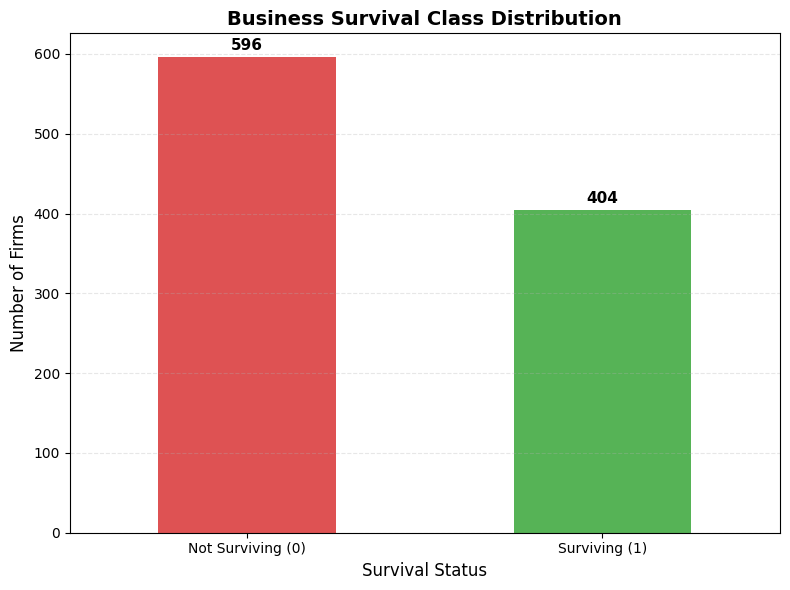

Saved: class_distribution.png




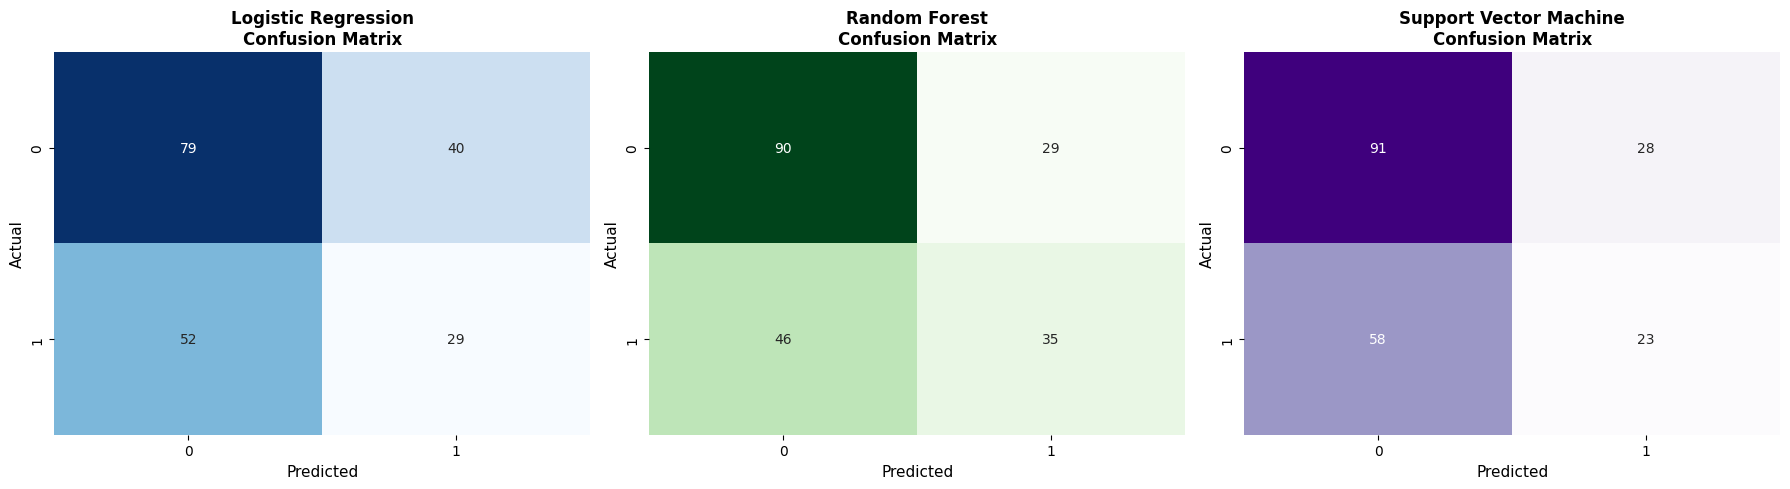

Saved: confusion_matrices.png




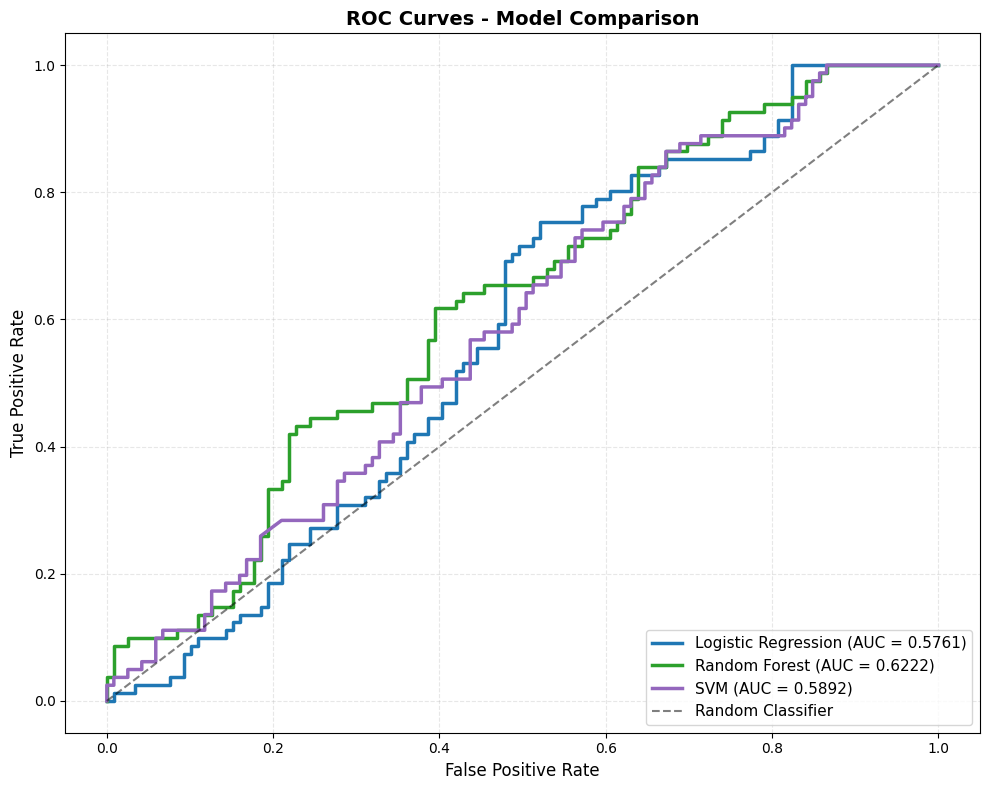

Saved: roc_curves.png




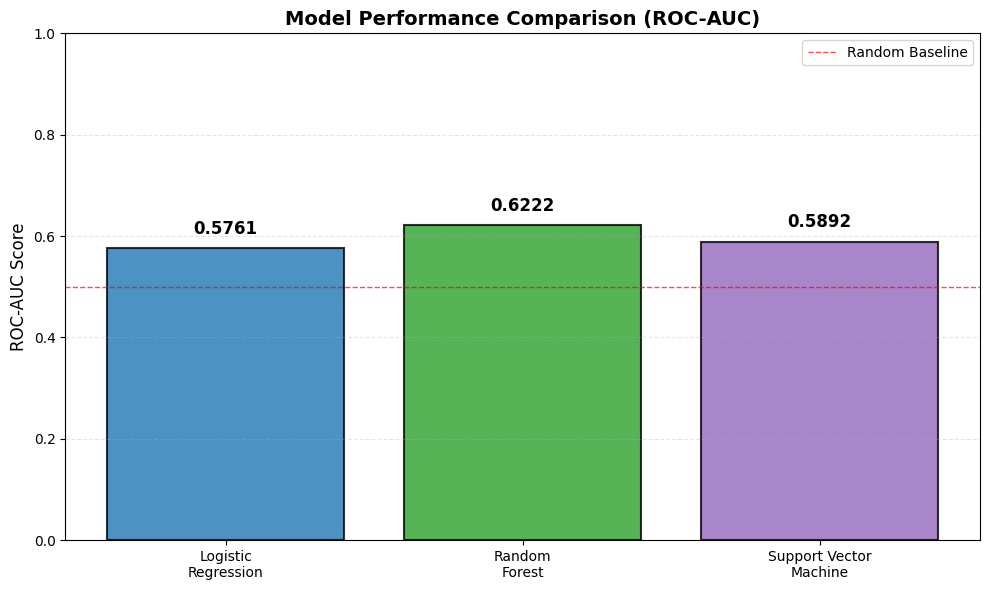

Saved: model_performance_comparison.png




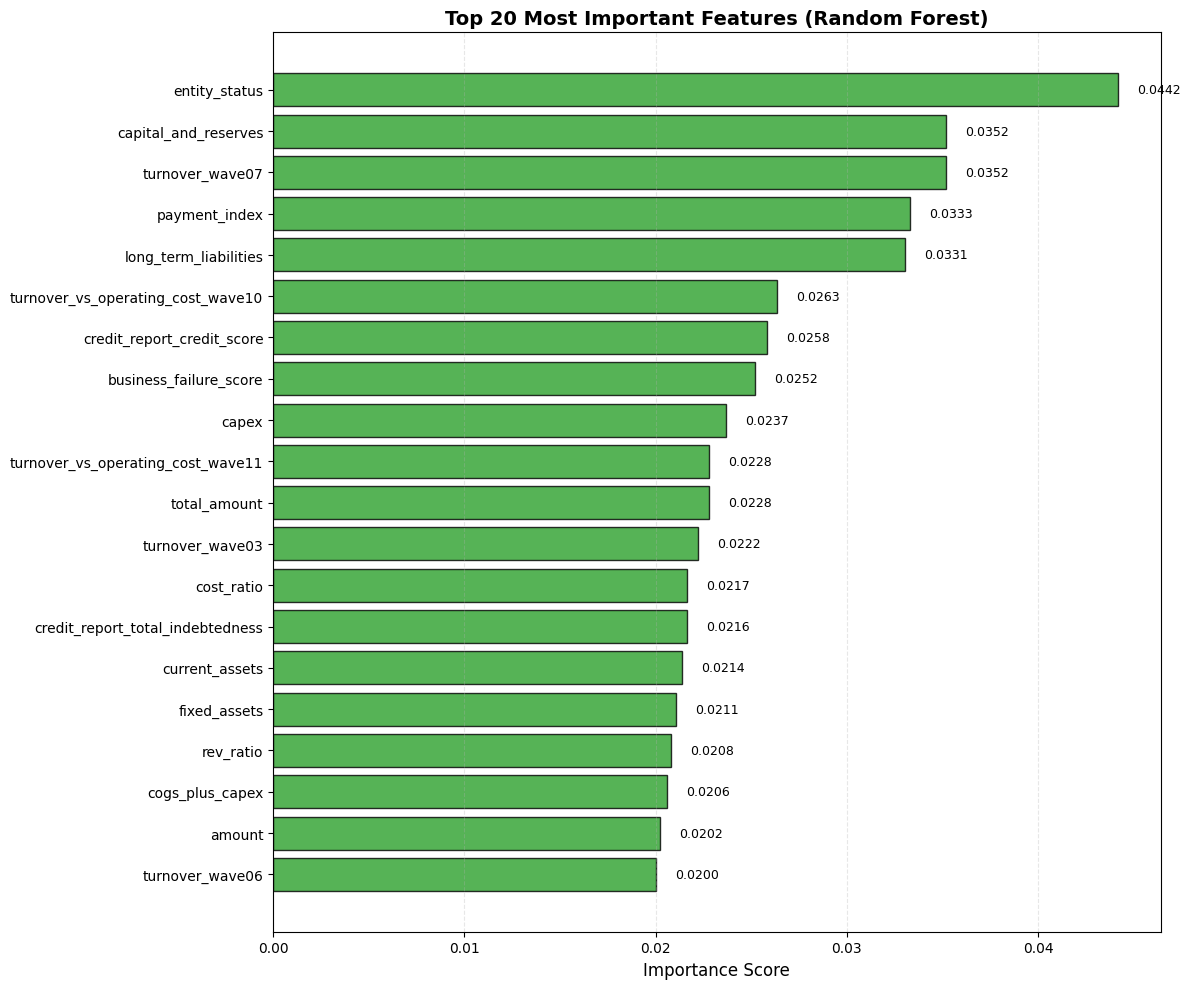

Saved: feature_importance.png




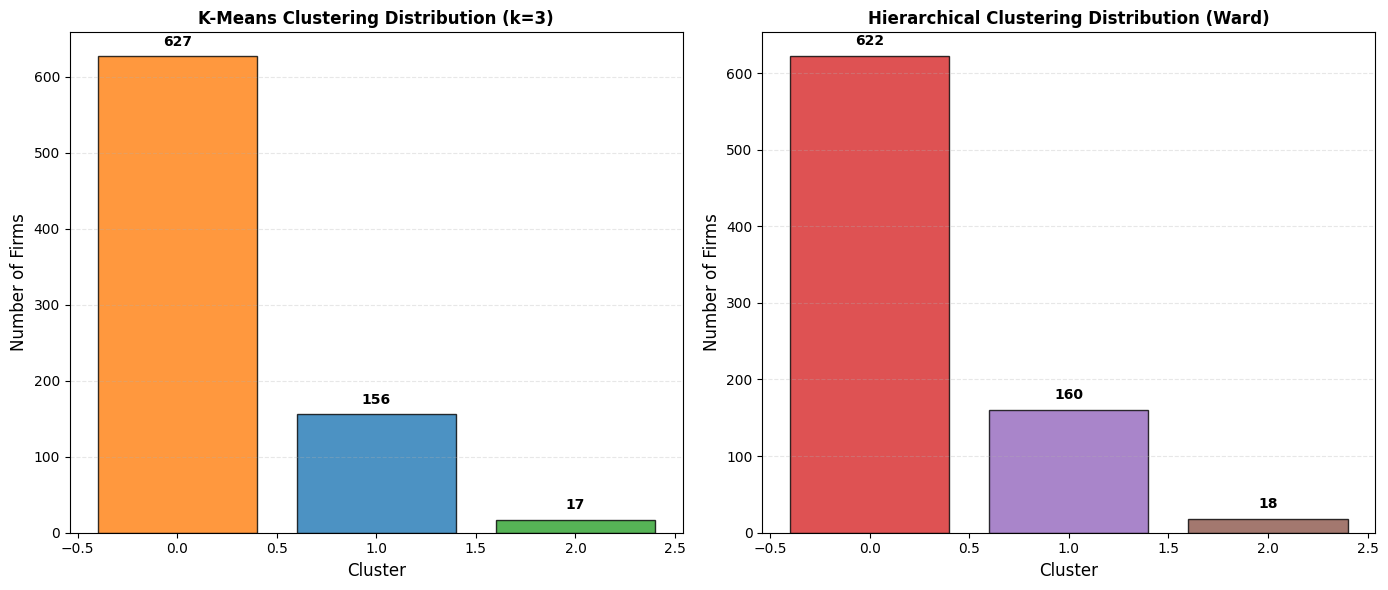

Saved: cluster_distribution.png


ANALYSIS COMPLETE
Total firms analyzed: 1000
Features used (waves 3-11): 78
Outcome variable: business_survival (based on waves 12-14)
Data leakage prevention: Wave 12-14 predictors removed
Aggregation level: Firm-level (one-to-many relationships aggregated)


Visualizations saved:
1. class_distribution.png
2. confusion_matrices.png
3. roc_curves.png
4. model_performance_comparison.png
5. feature_importance.png
6. cluster_distribution.png


All analysis and visualizations complete.


In [ ]:
# =========================================================
# Section 1: Environment Setup
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Environment setup complete")
print("\n")

# =========================================================
# Section 2: Data Loading
# =========================================================

business_df = pd.read_csv("Businesses.csv")
credit_rating_df = pd.read_csv("Credit_Rating.csv")
loan_df = pd.read_csv("Loan.csv")
credit_account_df = pd.read_csv("Credit_Account_History.csv")
credit_card_df = pd.read_csv("Credit_Card_History.csv")
receivable_df = pd.read_csv("Account_Receivable.csv")
factoring_df = pd.read_csv("Factoring.csv")
covid_df = pd.read_csv("COVID.csv")

print("Dataset shapes:")
print(f"Business: {business_df.shape}")
print(f"Credit Rating: {credit_rating_df.shape}")
print(f"Loan: {loan_df.shape}")
print(f"Credit Account: {credit_account_df.shape}")
print(f"Credit Card: {credit_card_df.shape}")
print(f"Receivable: {receivable_df.shape}")
print(f"Factoring: {factoring_df.shape}")
print(f"COVID: {covid_df.shape}")
print("\n")

# =========================================================
# Section 3: One-to-Many Relationship Aggregation
# =========================================================

print("Aggregating one-to-many relationships to firm level...")

if 'Unnamed: 0' in receivable_df.columns:
    receivable_df = receivable_df.drop(columns=['Unnamed: 0'])

receivable_agg = receivable_df.groupby('company_reg_number').agg({
    'invoice_amount': ['sum', 'mean', 'count'],
    'disputed': 'sum'
}).reset_index()
receivable_agg.columns = ['company_reg_number', 'total_invoice_amount', 'mean_invoice_amount',
                           'invoice_count', 'total_disputed']

print(f"Receivable aggregated shape: {receivable_agg.shape}")

if 'Unnamed: 0' in credit_account_df.columns:
    credit_account_df = credit_account_df.drop(columns=['Unnamed: 0'])

numeric_cols_credit_account = credit_account_df.select_dtypes(include=[np.number]).columns.tolist()
if 'company_reg_number' in numeric_cols_credit_account:
    numeric_cols_credit_account.remove('company_reg_number')

if numeric_cols_credit_account:
    agg_dict = {col: 'mean' for col in numeric_cols_credit_account}
    credit_account_agg = credit_account_df.groupby('company_reg_number').agg(agg_dict).reset_index()
else:
    credit_account_agg = credit_account_df[['company_reg_number']].drop_duplicates()

print(f"Credit account aggregated shape: {credit_account_agg.shape}")
print("\n")

# =========================================================
# Section 4: Dataset Integration
# =========================================================

for df_name in ['business_df', 'credit_rating_df', 'loan_df',
                'credit_card_df', 'factoring_df', 'covid_df']:
    df_obj = globals()[df_name]
    if 'Unnamed: 0' in df_obj.columns:
        globals()[df_name] = df_obj.drop(columns=['Unnamed: 0'])

df = business_df.copy()
df = df.merge(credit_rating_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(loan_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(credit_account_agg, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(credit_card_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(receivable_agg, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(factoring_df, on='company_reg_number', how='left', suffixes=('', '_dup'))
df = df.merge(covid_df, on='company_reg_number', how='left', suffixes=('', '_dup'))

duplicate_cols = [col for col in df.columns if col.endswith('_dup')]
if duplicate_cols:
    df = df.drop(columns=duplicate_cols)

print(f"Integrated dataset shape (firm-level): {df.shape}")
print(f"Unique companies: {df['company_reg_number'].nunique()}")
print("\n")

# =========================================================
# Section 5: Data Cleaning and Preparation
# =========================================================

df = df.drop_duplicates(subset='company_reg_number')
print(f"Shape after ensuring one record per firm: {df.shape}")

text_columns = [col for col in df.columns if df[col].dtype == 'object']
df = df.drop(columns=text_columns, errors='ignore')
print(f"Shape after removing text columns: {df.shape}")

numeric_df = df.select_dtypes(include=[np.number])
print(f"Shape after selecting numeric columns: {numeric_df.shape}")

unnamed_cols = [col for col in numeric_df.columns if 'Unnamed' in col]
if unnamed_cols:
    numeric_df = numeric_df.drop(columns=unnamed_cols)
    print(f"Dropped {len(unnamed_cols)} unnamed columns")

numeric_df = numeric_df.drop(columns=['company_reg_number'], errors='ignore')

print(f"Missing values before imputation: {numeric_df.isna().sum().sum()}")

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
print(f"Missing values after replacing inf: {numeric_df.isna().sum().sum()}")

all_nan_cols = numeric_df.columns[numeric_df.isna().all()].tolist()
if all_nan_cols:
    numeric_df = numeric_df.drop(columns=all_nan_cols)
    print(f"Dropped {len(all_nan_cols)} all-NaN columns")

col_medians = numeric_df.median()
numeric_df = numeric_df.fillna(col_medians)

remaining_nan_cols = numeric_df.columns[numeric_df.isna().any()].tolist()
if remaining_nan_cols:
    for col in remaining_nan_cols:
        numeric_df[col] = numeric_df[col].fillna(0)

print(f"Final missing values count: {numeric_df.isna().sum().sum()}")
print(f"Final shape: {numeric_df.shape}")
print("\n")

# =========================================================
# Section 6: Survival Proxy Construction
# =========================================================

print("Constructing business survival target using waves 12-14...")

cost_comparison_cols = [col for col in numeric_df.columns if 'turnover_vs_operating_cost_wave' in col.lower()]

wave_12_comparison = [col for col in cost_comparison_cols if 'wave12' in col.lower() or 'wave_12' in col.lower()]
wave_13_comparison = [col for col in cost_comparison_cols if 'wave13' in col.lower() or 'wave_13' in col.lower()]
wave_14_comparison = [col for col in cost_comparison_cols if 'wave14' in col.lower() or 'wave_14' in col.lower()]

viability_columns = []
if wave_12_comparison:
    viability_columns.extend(wave_12_comparison)
if wave_13_comparison:
    viability_columns.extend(wave_13_comparison)
if wave_14_comparison:
    viability_columns.extend(wave_14_comparison)

print(f"Using {len(viability_columns)} columns for survival proxy: {viability_columns}")

viability_scores = numeric_df[viability_columns].mean(axis=1)
numeric_df['business_survival'] = (viability_scores > 0).astype(int)

print("Survival target class distribution:")
print(numeric_df['business_survival'].value_counts())
print("\n")

class_counts = numeric_df['business_survival'].value_counts()
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Class imbalance ratio: {imbalance_ratio:.4f}")
print("\n")

# =========================================================
# Section 7: Temporal Leakage Prevention
# =========================================================

print("Removing wave 12-14 variables to prevent data leakage...")

wave_12_14_patterns = ['wave12', 'wave_12', 'wave13', 'wave_13', 'wave14', 'wave_14']
leakage_columns = []

for col in numeric_df.columns:
    if col == 'business_survival':
        continue
    col_lower = col.lower()
    if any(pattern in col_lower for pattern in wave_12_14_patterns):
        leakage_columns.append(col)

print(f"Identified {len(leakage_columns)} wave 12-14 columns for removal:")
print(leakage_columns)

numeric_df = numeric_df.drop(columns=leakage_columns)

print(f"Shape after removing wave 12-14 variables: {numeric_df.shape}")
print(f"Remaining features (excluding target): {numeric_df.shape[1] - 1}")
print("\n")

# =========================================================
# Section 8: Feature-Target Separation
# =========================================================

X = numeric_df.drop('business_survival', axis=1)
y = numeric_df['business_survival']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features retained for modelling: {X.shape[1]}")

print(f"NaN check - X: {X.isna().sum().sum()}, y: {y.isna().sum()}")
print("\n")

# =========================================================
# Section 9: Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} firms")
print(f"Test set size: {X_test.shape[0]} firms")
print("\n")

print("Training set class distribution:")
print(y_train.value_counts())
print("\n")

print("Test set class distribution:")
print(y_test.value_counts())
print("\n")

# =========================================================
# Section 10: Feature Scaling
# =========================================================

print(f"NaN values in X_train before scaling: {X_train.isna().sum().sum()}")
print(f"NaN values in X_test before scaling: {X_test.isna().sum().sum()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

per_feature_means = X_train_scaled.mean(axis=0)
per_feature_stds = X_train_scaled.std(axis=0)

print(f"Per-feature mean range: [{per_feature_means.min():.6f}, {per_feature_means.max():.6f}]")
print(f"Per-feature std range: [{per_feature_stds.min():.6f}, {per_feature_stds.max():.6f}]")
print(f"Mean of per-feature means: {per_feature_means.mean():.6f}")
print(f"Mean of per-feature stds: {per_feature_stds.mean():.6f}")

print(f"NaN values in scaled training set: {np.isnan(X_train_scaled).sum()}")
print(f"NaN values in scaled test set: {np.isnan(X_test_scaled).sum()}")

if np.isnan(X_train_scaled).sum() > 0:
    print("WARNING: NaN values detected after scaling. Applying final imputation.")
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    print(f"NaN values after final imputation - train: {np.isnan(X_train_scaled).sum()}, test: {np.isnan(X_test_scaled).sum()}")

print("\n")

# =========================================================
# Section 11: Clustering (Exploratory, Managerial Insight)
# =========================================================

print("Performing clustering analysis for managerial segmentation...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

print("K-Means Clustering Results (k=3):")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} firms ({count/len(kmeans_labels)*100:.1f}%)")
print("\n")

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_train_scaled)

print("Hierarchical Clustering Results (Ward linkage, k=3):")
unique, counts = np.unique(hierarchical_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} firms ({count/len(hierarchical_labels)*100:.1f}%)")
print("\n")

# =========================================================
# Section 12: Classification Models
# =========================================================

print("Training Logistic Regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression training complete")
print("\n")

print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest training complete")
print("\n")

print("Training Support Vector Machine model...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True, C=1.0)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
print("Support Vector Machine training complete")
print("\n")

# =========================================================
# Section 13: Model Evaluation
# =========================================================

print("="*60)
print("LOGISTIC REGRESSION EVALUATION")
print("="*60)
print(classification_report(y_test, lr_pred, digits=4))
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
print(f"ROC-AUC Score: {lr_auc:.4f}")
print("\n")

print("="*60)
print("RANDOM FOREST EVALUATION")
print("="*60)
print(classification_report(y_test, rf_pred, digits=4))
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"ROC-AUC Score: {rf_auc:.4f}")
print("\n")

print("="*60)
print("SUPPORT VECTOR MACHINE EVALUATION")
print("="*60)
print(classification_report(y_test, svm_pred, digits=4))
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_auc = roc_auc_score(y_test, svm_proba)
print(f"ROC-AUC Score: {svm_auc:.4f}")
print("\n")

print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Support Vector Machine'],
    'ROC-AUC': [lr_auc, rf_auc, svm_auc]
})
print(results_df.to_string(index=False))
print("\n")

print("="*60)
print("FEATURE IMPORTANCE ANALYSIS (RANDOM FOREST)")
print("="*60)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))
print("\n")

# =========================================================
# Section 14: Visualization - Class Distribution
# =========================================================

print("Generating visualizations...")
print("\n")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
class_counts.plot(kind='bar', ax=ax, color=['#d62728', '#2ca02c'], alpha=0.8)
ax.set_title('Business Survival Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Survival Status', fontsize=12)
ax.set_ylabel('Number of Firms', fontsize=12)
ax.set_xticklabels(['Not Surviving (0)', 'Surviving (1)'], rotation=0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")
print("\n")

# =========================================================
# Section 15: Visualization - Confusion Matrices
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False)
axes[2].set_title('Support Vector Machine\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted', fontsize=11)
axes[2].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")
print("\n")

# =========================================================
# Section 16: Visualization - ROC Curves
# =========================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', linewidth=2.5, color='#1f77b4')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.4f})', linewidth=2.5, color='#2ca02c')
ax.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {svm_auc:.4f})', linewidth=2.5, color='#9467bd')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier', alpha=0.5)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")
print("\n")

# =========================================================
# Section 17: Visualization - Model Performance Comparison
# =========================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['Logistic\nRegression', 'Random\nForest', 'Support Vector\nMachine']
auc_scores = [lr_auc, rf_auc, svm_auc]
colors = ['#1f77b4', '#2ca02c', '#9467bd']

bars = ax.bar(models, auc_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Model Performance Comparison (ROC-AUC)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Random Baseline')

for i, (bar, score) in enumerate(zip(bars, auc_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: model_performance_comparison.png")
print("\n")

# =========================================================
# Section 18: Visualization - Feature Importance
# =========================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

top_n = 20
top_features = feature_importance.head(top_n)

bars = ax.barh(range(top_n), top_features['importance'].values, color='#2ca02c', alpha=0.8, edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values, fontsize=10)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")
print("\n")

# =========================================================
# Section 19: Visualization - Cluster Distribution
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

kmeans_cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
axes[0].bar(kmeans_cluster_counts.index, kmeans_cluster_counts.values,
            color=['#ff7f0e', '#1f77b4', '#2ca02c'], alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Number of Firms', fontsize=12)
axes[0].set_title('K-Means Clustering Distribution (k=3)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(kmeans_cluster_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

hierarchical_cluster_counts = pd.Series(hierarchical_labels).value_counts().sort_index()
axes[1].bar(hierarchical_cluster_counts.index, hierarchical_cluster_counts.values,
            color=['#d62728', '#9467bd', '#8c564b'], alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Number of Firms', fontsize=12)
axes[1].set_title('Hierarchical Clustering Distribution (Ward)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(hierarchical_cluster_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: cluster_distribution.png")
print("\n")

# =========================================================
# Section 20: Final Summary
# =========================================================

print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"Total firms analyzed: {numeric_df.shape[0]}")
print(f"Features used (waves 3-11): {X.shape[1]}")
print(f"Outcome variable: business_survival (based on waves 12-14)")
print(f"Data leakage prevention: Wave 12-14 predictors removed")
print(f"Aggregation level: Firm-level (one-to-many relationships aggregated)")
print("\n")
print("Visualizations saved:")
print("1. class_distribution.png")
print("2. confusion_matrices.png")
print("3. roc_curves.png")
print("4. model_performance_comparison.png")
print("5. feature_importance.png")
print("6. cluster_distribution.png")
print("\n")
print("All analysis and visualizations complete.")